In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv("salaries.csv")
df.head()

,Years of Experience,Education Level,Age,Location Factor,Salary
0,29,1,49,7,124204
1,27,3,45,4,125948
2,20,4,41,8,116078
3,14,4,37,5,106486
4,20,3,42,7,113297


In [2]:
df.shape

(1000, 5)

In [3]:
X=df.drop('Salary',axis=1)
y=df['Salary']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

model_full=LinearRegression()
model_full.fit(X_train, y_train)
model_full.score(X_test, y_test)

0.9525773624816918

In [5]:
model_full.intercept_

np.float64(52608.487605282426)

In [6]:
model_full.coef_

array([2113.98280589, 5007.82035443, -123.21488799, 1487.64526717])

In [7]:
y_test[:1]

841    151272
Name: Salary, dtype: int64

In [8]:
model_full.predict(X_test[:1])

array([144436.42826039])

In [9]:
X_test[:1]

,Years of Experience,Education Level,Age,Location Factor
841,38,1,56,9


In [11]:
38*model_full.coef_[0]+1*model_full.coef_[1]+56*model_full.coef_[2]+9*model_full.coef_[3]+model_full.intercept_

np.float64(144436.42826039356)

<Axes: xlabel='Age', ylabel='Salary'>

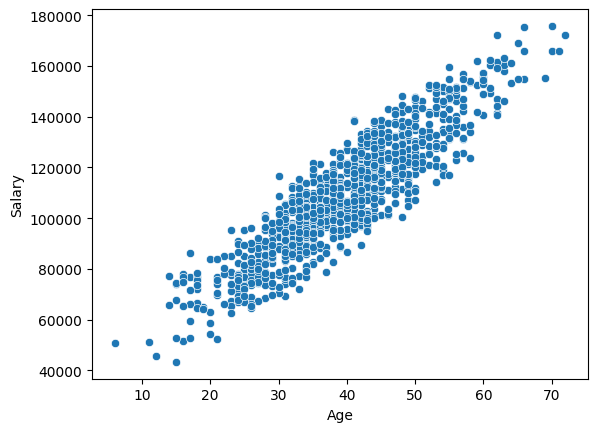

In [14]:
sns.scatterplot(df,x='Age',y='Salary')

<Axes: >

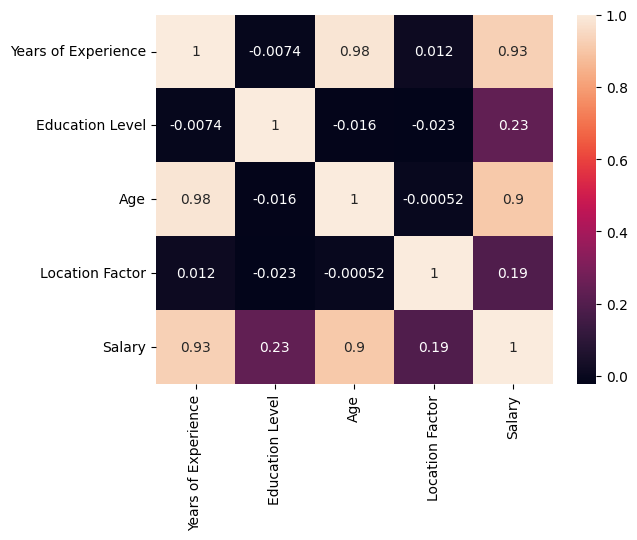

In [15]:
cm=df.corr()
sns.heatmap(cm,annot=True)

In [16]:
df.values

array([[    29,      1,     49,      7, 124204],
       [    27,      3,     45,      4, 125948],
       [    20,      4,     41,      8, 116078],
       ...,
       [    13,      3,     33,      8, 100478],
       [    19,      2,     40,      2, 100085],
       [    16,      2,     36,      9, 103222]], shape=(1000, 5))

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df=pd.DataFrame()
    vif_df['varables']=data.columns
    vif_df['VIF']=[variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [28]:
X=df.drop('Salary',axis='columns')
calculate_vif(X)

,varables,VIF
0,Years of Experience,22.342087
1,Education Level,5.472969
2,Age,42.201149
3,Location Factor,4.289467


In [29]:
calculate_vif(X.drop("Age",axis=1))

,varables,VIF
0,Years of Experience,3.198601
1,Education Level,3.509425
2,Location Factor,3.231181


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X.drop("Age",axis=1), y, test_size=0.2, random_state=10)

model_full=LinearRegression()
model_full.fit(X_train, y_train)
model_full.score(X_test, y_test)

0.9523792255284542

In [31]:
model_full.coef_

array([1995.01818661, 5019.90803026, 1495.54971534])